# Notebook 18 — Coefficient baselines and validation

## Aim

Compare the frozen Notebook 14 neural networks with piecewise-linear and PCHIP interpolation for predicting the small-species volume-fraction field from particle-size ratio $\mu$.

## Fixed comparison

- Evaluate ranks $r=6$ and $r=15$ separately, using the exact saved uncentred POD bases and raw coefficients.
- Compare `frozen_nn`, `piecewise_linear` and `pchip`.
- Use exactly the 90 saved coefficient-fitting cases as interpolation nodes.
- Evaluate the ten saved internal-validation cases and ten external cases separately; retain fitting diagnostics with explicit role labels.
- Disable extrapolation. No smoothing, parameter sweep, network retraining or rank selection is part of this comparison.
- Report every method, including any that performs poorly.

## Error definitions

For truth field $q$, frozen orthonormal basis $\Phi_r$ and predicted coefficients $\widehat a(\mu)$,

$$
a^*=\Phi_r^\mathsf{T}q,
\qquad
\widehat q=\Phi_r\widehat a.
$$

$$
e_{\mathrm{POD}}=
\frac{\lVert q-\Phi_r a^*\rVert_2}{\lVert q\rVert_2},
\qquad
e_{\mathrm{coef}}=
\frac{\lVert a^*-\widehat a\rVert_2}{\lVert q\rVert_2},
\qquad
e_{\mathrm{ROM}}=
\frac{\lVert q-\widehat q\rVert_2}{\lVert q\rVert_2}.
$$

Verify for every evaluated case:

$$
e_{\mathrm{ROM}}^2=e_{\mathrm{POD}}^2+e_{\mathrm{coef}}^2.
$$

Report errors as percentages, with mean, median and maximum summaries and paired differences between methods. Also report field-integral error, extrema and grid fractions below $-10^{-4}$ or above one, matching Notebook 14's diagnostic thresholds.

## Interpretation and scope

The frozen bases were constructed using all 100 original training-collection fields, including the ten coefficient-validation fields. This is therefore a comparison of coefficient maps **conditional on those bases**, not a validation of a completely training-only fitting pipeline.

The external cases have already been inspected during the project. Their scores provide a **retrospective external comparison**, not a newly blind test. Evaluation truths must not enter construction of the interpolants.

The historical final-sweep seeds are 11, 47 and 131. Their archived validation results will be summarised separately from the earlier five-seed scaling experiment.

Inputs are the compact saved continuum dataset, trusted model packages and saved tables. New artifacts will be saved under `results/tables/coefficient_baselines/` and `results/figures/coefficient_baselines/`, with a final manifest after the results and conclusions are complete.

The first code cell is a read-only preflight. The four subsequent stages will audit/load the models, construct interpolants, evaluate them, and save the results.


In [2]:
import hashlib
import json
import sys
from datetime import datetime, timezone
from importlib.metadata import version
from pathlib import Path

N18_REPO_ROOT = Path.home() / "Documents" / "msc-rom-particle-systems"
N18_RANKS = (6, 15)
N18_METHODS = ("frozen_nn", "piecewise_linear", "pchip")
N18_FINAL_SWEEP_SEEDS = (11, 47, 131)
N18_NEGATIVE_THRESHOLD = -1e-4
N18_PROTOCOL_FROZEN_AT_UTC = datetime.now(timezone.utc).isoformat()

print("Python executable:", sys.executable)
print("Repository root:", N18_REPO_ROOT)
assert N18_REPO_ROOT.is_dir(), "Repository directory was not found."
assert Path(sys.prefix).resolve() == (N18_REPO_ROOT / ".venv").resolve(), (
    "This kernel is not using the repository .venv. "
    "Select the repository Python kernel before continuing."
)

N18_VERSIONS = {
    name: version(name)
    for name in ("numpy", "pandas", "scipy", "torch", "matplotlib")
}
import pandas as pd
from IPython.display import display

N18_N14_TABLE_ROOT = "results/tables/exact_paper_method_reproduction"
N18_MANIFEST_PATH = N18_REPO_ROOT / N18_N14_TABLE_ROOT / (
    "exact_paper_method_reproduction_manifest.json"
)
# Manifest hash recorded in Notebook 15's successful audit.
N18_EXPECTED_MANIFEST_SHA256 = (
    "f15744e23b1bfc3898750a1e2fb2504a2d3ca9c6c96c714188a4094d0357604f"
)
N18_INPUT_RELATIVE_PATHS = {
    "dataset": "data/processed/cg_phi_small_dataset.npz",
    "rank_6_package": (
        "data/processed/cg_phi_validation_selected_rank_uncentred_raw.pt"
    ),
    "rank_15_package": "data/processed/cg_phi_paper_rank15_uncentred_raw.pt",
    "final_case_errors": f"{N18_N14_TABLE_ROOT}/final_continuum_rom_test_cases.csv",
    "final_summary": f"{N18_N14_TABLE_ROOT}/final_continuum_rom_comparison.csv",
    "restart_results": f"{N18_N14_TABLE_ROOT}/paper_rank_training_restart_results.csv",
    "selected_models": f"{N18_N14_TABLE_ROOT}/paper_rank_training_selected_models.csv",
}


def n18_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


assert N18_MANIFEST_PATH.is_file(), f"Missing manifest: {N18_MANIFEST_PATH}"
N18_MANIFEST_SHA256 = n18_sha256(N18_MANIFEST_PATH)
print("Notebook 14 manifest SHA-256:", N18_MANIFEST_SHA256)
assert N18_MANIFEST_SHA256 == N18_EXPECTED_MANIFEST_SHA256, (
    "The manifest differs from the final hash stored in the uploaded Notebook 14. "
    "Stop here and report both hashes."
)
N18_MANIFEST = json.loads(N18_MANIFEST_PATH.read_text(encoding="utf-8"))
assert N18_MANIFEST["schema_version"] == 1
assert N18_MANIFEST["notebook"] == "14_exact_paper_method_reproduction.ipynb"

n18_design = N18_MANIFEST["training_design"]
assert n18_design["fitting_cases"] == 90
assert n18_design["validation_cases"] == 10
assert n18_design["external_test_used_for_selection"] is False
assert tuple(sorted(n18_design["sweep_restart_seeds"])) == N18_FINAL_SWEEP_SEEDS
assert N18_MANIFEST["dataset"]["training_cases"] == 100
assert N18_MANIFEST["dataset"]["external_test_cases"] == 10
assert N18_MANIFEST["paper_interpretation"]["pod_formulation"] == "uncentred"
assert N18_MANIFEST["paper_interpretation"]["coefficient_scaling_primary"] == "none"

N18_INPUT_RECORDS = {}
for record in [N18_MANIFEST["dataset"], *N18_MANIFEST["artifacts"]]:
    relative_path = record["relative_path"]
    assert relative_path not in N18_INPUT_RECORDS, (
        f"Duplicate manifest path: {relative_path}"
    )
    N18_INPUT_RECORDS[relative_path] = record

N18_INPUT_PATHS = {}
n18_preflight_rows = []
for role, relative_path in N18_INPUT_RELATIVE_PATHS.items():
    assert relative_path in N18_INPUT_RECORDS, f"Not in manifest: {relative_path}"
    path = N18_REPO_ROOT / relative_path
    assert path.is_file(), f"Missing input: {path}"
    record = N18_INPUT_RECORDS[relative_path]
    observed_hash = n18_sha256(path)
    hash_match = observed_hash == record["sha256"]
    print(f"{role}: SHA-256 {observed_hash}; match={hash_match}")
    assert hash_match, f"Input hash mismatch: {path}"
    if "size_bytes" in record:
        assert path.stat().st_size == record["size_bytes"], (
            f"Input size mismatch: {path}"
        )
    N18_INPUT_PATHS[role] = path
    n18_preflight_rows.append({
        "input_role": role,
        "size_MiB": path.stat().st_size / (1024 ** 2),
        "hash_match": hash_match,
    })

N18_PREFLIGHT_AUDIT = pd.DataFrame(n18_preflight_rows)
display(N18_PREFLIGHT_AUDIT)
print("Package versions:", N18_VERSIONS)
print("Ranks:", N18_RANKS)
print("Methods:", N18_METHODS)
print("Protocol frozen at UTC:", N18_PROTOCOL_FROZEN_AT_UTC)
print("Numerical dataset arrays loaded:", False)
print("Model packages deserialised:", False)
print("Raw DEM files accessed:", False)
print("Files written by this cell:", False)
print("Notebook 18 preflight passed:", True)


Python executable: /Users/rallen/Documents/msc-rom-particle-systems/.venv/bin/python
Repository root: /Users/rallen/Documents/msc-rom-particle-systems
Notebook 14 manifest SHA-256: f15744e23b1bfc3898750a1e2fb2504a2d3ca9c6c96c714188a4094d0357604f
dataset: SHA-256 6915b428fee927d6ed3beecc4b5947bad0eb4895ee2b59d5ddaa086b4af11e56; match=True
rank_6_package: SHA-256 df716ccd732b88e67a73eec7873d33ba5efb9c9b5bc7ca30aec2fe99f1edacf7; match=True
rank_15_package: SHA-256 571c12493edd5782859f617316badd4b58402b2b06a90e6d03fddccf6baea516; match=True
final_case_errors: SHA-256 7b8e495ed1b8197ef2033d9ed3d52d41e5d4ce7990828cd05353fa2d671fce31; match=True
final_summary: SHA-256 5ed41a23ddd2a10de7f9526f595ee72e3019a5c7eeb76f29c624a50f1a55d30c; match=True
restart_results: SHA-256 211c92624b181c5b944c4967fcd95ea7d545254951e2dfc058b2bb9c056d3358; match=True
selected_models: SHA-256 2b00575f85373755d66a220d30d91908029007056c34eddc4fe424d31b367367; match=True


,input_role,size_MiB,hash_match
0,dataset,3.253745,True
1,rank_6_package,0.594852,True
2,rank_15_package,1.482677,True
3,final_case_errors,0.001550,True
4,final_summary,0.000975,True
5,restart_results,0.006591,True
6,selected_models,0.002498,True


Package versions: {'numpy': '1.26.4', 'pandas': '3.0.3', 'scipy': '1.17.1', 'torch': '2.2.2', 'matplotlib': '3.11.0'}
Ranks: (6, 15)
Methods: ('frozen_nn', 'piecewise_linear', 'pchip')
Protocol frozen at UTC: 2026-09-06T13:51:02.689403+00:00
Numerical dataset arrays loaded: False
Model packages deserialised: False
Raw DEM files accessed: False
Files written by this cell: False
Notebook 18 preflight passed: True


In [3]:
import numpy as np
import pandas as pd
import torch

from IPython.display import display


torch.set_num_threads(1)


with np.load(
    N18_INPUT_PATHS["dataset"],
    allow_pickle=False,
) as n18_dataset:

    N18_X_GRID = n18_dataset["x"]
    N18_Z_GRID = n18_dataset["z"]

    N18_TRAIN_PARAMETERS = (
        n18_dataset["train_parameters"]
    )

    N18_TEST_PARAMETERS = (
        n18_dataset["test_parameters"]
    )

    N18_TRAIN_SIMULATION_NUMBERS = (
        n18_dataset["train_simulation_numbers"]
    )

    N18_TEST_SIMULATION_NUMBERS = (
        n18_dataset["test_simulation_numbers"]
    )

    N18_TRAIN_FILENAMES = (
        n18_dataset["train_filenames"]
    )

    N18_TEST_FILENAMES = (
        n18_dataset["test_filenames"]
    )

    N18_TRAIN_SNAPSHOT_MATRIX = (
        n18_dataset["train_snapshots"]
    )

    N18_TEST_SNAPSHOT_MATRIX = (
        n18_dataset["test_snapshots"]
    )


assert N18_X_GRID.shape == (100,)
assert N18_Z_GRID.shape == (100,)
assert N18_TRAIN_PARAMETERS.shape == (100,)
assert N18_TEST_PARAMETERS.shape == (10,)

assert N18_TRAIN_SNAPSHOT_MATRIX.shape == (
    10000,
    100,
)

assert N18_TEST_SNAPSHOT_MATRIX.shape == (
    10000,
    10,
)

assert np.all(np.diff(N18_X_GRID) > 0)
assert np.all(np.diff(N18_Z_GRID) > 0)
assert np.all(np.diff(N18_TRAIN_PARAMETERS) > 0)

assert np.isfinite(
    N18_TRAIN_SNAPSHOT_MATRIX
).all()

assert np.isfinite(
    N18_TEST_SNAPSHOT_MATRIX
).all()

assert np.intersect1d(
    N18_TRAIN_PARAMETERS,
    N18_TEST_PARAMETERS,
).size == 0


class N18FrozenNetwork(
    torch.nn.Module
):

    def __init__(
        self,
        input_dimension,
        output_dimension,
        hidden_width,
    ):
        super().__init__()

        self.network = torch.nn.Sequential(
            torch.nn.Linear(
                input_dimension,
                hidden_width,
                dtype=torch.float64,
            ),
            torch.nn.Tanh(),
            torch.nn.Linear(
                hidden_width,
                hidden_width,
                dtype=torch.float64,
            ),
            torch.nn.Tanh(),
            torch.nn.Linear(
                hidden_width,
                output_dimension,
                dtype=torch.float64,
            ),
        )

    def forward(self, inputs):
        return self.network(inputs)


N18_PACKAGE_SPECS = {
    "validation_selected_rank": {
        "role": "rank_6_package",
        "rank": 6,
    },
    "paper_rank15": {
        "role": "rank_15_package",
        "rank": 15,
    },
}


N18_FROZEN_PACKAGES = {}
N18_FROZEN_NETWORKS = {}
N18_FROZEN_AUDIT_ROWS = []


for (
    n18_model_name,
    n18_spec,
) in N18_PACKAGE_SPECS.items():

    n18_package = torch.load(
        N18_INPUT_PATHS[
            n18_spec["role"]
        ],
        map_location="cpu",
    )

    n18_rank = int(
        n18_package["rank"]
    )

    n18_hidden_width = int(
        n18_package["hidden_width"]
    )

    n18_training_indices = np.asarray(
        n18_package["training_indices"],
        dtype=int,
    )

    n18_validation_indices = np.asarray(
        n18_package["validation_indices"],
        dtype=int,
    )

    n18_basis = np.asarray(
        n18_package["pod_basis"],
        dtype=float,
    )

    assert n18_rank == n18_spec["rank"]

    assert n18_hidden_width == (
        3 * (1 + n18_rank)
    )

    assert int(
        n18_package["input_dimension"]
    ) == 1

    assert float(
        n18_package["parameter_minimum"]
    ) == 1.0

    assert float(
        n18_package["parameter_maximum"]
    ) == 2.0

    assert (
        n18_package["coefficient_scaling"]
        == "none"
    )

    assert (
        n18_package["pod_formulation"]
        == "uncentred"
    )

    assert n18_basis.shape == (
        10000,
        n18_rank,
    )

    assert np.isfinite(
        n18_basis
    ).all()

    assert np.array_equal(
        np.asarray(
            n18_package["x_grid"],
            dtype=float,
        ),
        N18_X_GRID,
    )

    assert np.array_equal(
        np.asarray(
            n18_package["z_grid"],
            dtype=float,
        ),
        N18_Z_GRID,
    )

    assert len(
        n18_training_indices
    ) == 90

    assert len(
        n18_validation_indices
    ) == 10

    assert set(
        n18_training_indices
    ).isdisjoint(
        set(n18_validation_indices)
    )

    assert (
        set(n18_training_indices)
        | set(n18_validation_indices)
    ) == set(range(100))

    n18_orthonormality_residual = float(
        np.max(
            np.abs(
                n18_basis.T @ n18_basis
                - np.eye(n18_rank)
            )
        )
    )

    assert (
        n18_orthonormality_residual
        < 1e-12
    )

    n18_network = N18FrozenNetwork(
        input_dimension=int(
            n18_package["input_dimension"]
        ),
        output_dimension=n18_rank,
        hidden_width=n18_hidden_width,
    )

    n18_network.load_state_dict(
        n18_package["state_dict"]
    )

    n18_network.eval()

    N18_FROZEN_PACKAGES[
        n18_model_name
    ] = n18_package

    N18_FROZEN_NETWORKS[
        n18_model_name
    ] = n18_network

    N18_FROZEN_AUDIT_ROWS.append(
        {
            "model": n18_model_name,
            "rank": n18_rank,
            "hidden_width": n18_hidden_width,
            "training_count": len(
                n18_training_indices
            ),
            "validation_count": len(
                n18_validation_indices
            ),
            "basis_orthonormality_residual": (
                n18_orthonormality_residual
            ),
            "random_seed": int(
                n18_package["random_seed"]
            ),
        }
    )


n18_reference_training_indices = np.asarray(
    N18_FROZEN_PACKAGES[
        "paper_rank15"
    ]["training_indices"],
    dtype=int,
)

n18_reference_validation_indices = np.asarray(
    N18_FROZEN_PACKAGES[
        "paper_rank15"
    ]["validation_indices"],
    dtype=int,
)


for (
    n18_model_name,
    n18_package,
) in N18_FROZEN_PACKAGES.items():

    assert np.array_equal(
        np.sort(
            np.asarray(
                n18_package["training_indices"],
                dtype=int,
            )
        ),
        np.sort(
            n18_reference_training_indices
        ),
    )

    assert np.array_equal(
        np.sort(
            np.asarray(
                n18_package["validation_indices"],
                dtype=int,
            )
        ),
        np.sort(
            n18_reference_validation_indices
        ),
    )


def n18_scale_parameters(
    parameter_values,
):

    values = np.asarray(
        parameter_values,
        dtype=float,
    ).reshape(-1)

    return (
        2.0
        * (values - 1.0)
        / (2.0 - 1.0)
        - 1.0
    ).reshape(-1, 1)


def n18_predict_coefficients(
    model_name,
    parameter_values,
):

    inputs = torch.tensor(
        n18_scale_parameters(
            parameter_values
        ),
        dtype=torch.float64,
    )

    with torch.no_grad():
        return (
            N18_FROZEN_NETWORKS[
                model_name
            ](inputs)
            .cpu()
            .numpy()
        )


def n18_predict_fields(
    model_name,
    parameter_values,
):

    n18_package = (
        N18_FROZEN_PACKAGES[
            model_name
        ]
    )

    n18_coefficients = (
        n18_predict_coefficients(
            model_name,
            parameter_values,
        )
    )

    n18_basis = np.asarray(
        n18_package["pod_basis"],
        dtype=float,
    )

    return (
        n18_basis
        @ n18_coefficients.T
    )


N18_FROZEN_PREDICTIONS = {
    model_name: n18_predict_fields(
        model_name,
        N18_TEST_PARAMETERS,
    )
    for model_name in N18_PACKAGE_SPECS
}


print(
    "Dataset shapes:",
    N18_TRAIN_SNAPSHOT_MATRIX.shape,
    N18_TEST_SNAPSHOT_MATRIX.shape,
)

display(
    pd.DataFrame(
        N18_FROZEN_AUDIT_ROWS
    )
)

print(
    "Frozen fitting/validation counts:",
    len(n18_reference_training_indices),
    len(n18_reference_validation_indices),
)

print(
    "Numerical arrays materialised:",
    True,
)

print(
    "Frozen model packages deserialised:",
    True,
)

print(
    "External cases used for fitting or selection:",
    False,
)

print(
    "Files written by this cell:",
    False,
)

print(
    "Notebook 18 frozen-input audit passed:",
    True,
)

Dataset shapes: (10000, 100) (10000, 10)


,model,rank,hidden_width,training_count,validation_count,basis_orthonormality_residual,random_seed
0,validation_selected_rank,6,21,90,10,1.998401e-15,131
1,paper_rank15,15,48,90,10,2.442491e-15,11


Frozen fitting/validation counts: 90 10
Numerical arrays materialised: True
Frozen model packages deserialised: True
External cases used for fitting or selection: False
Files written by this cell: False
Notebook 18 frozen-input audit passed: True


In [4]:
N18_FROZEN_CASE_ERRORS = {}
N18_FROZEN_DETERMINISM_ROWS = []


for n18_model_name in N18_PACKAGE_SPECS:

    n18_prediction_a = (
        N18_FROZEN_PREDICTIONS[
            n18_model_name
        ]
    )

    n18_prediction_b = (
        n18_predict_fields(
            n18_model_name,
            N18_TEST_PARAMETERS,
        )
    )

    n18_repeat_difference = float(
        np.max(
            np.abs(
                n18_prediction_a
                - n18_prediction_b
            )
        )
    )

    assert n18_repeat_difference == 0.0

    N18_FROZEN_DETERMINISM_ROWS.append(
        {
            "model": n18_model_name,
            "maximum_repeat_difference": (
                n18_repeat_difference
            ),
        }
    )

    N18_FROZEN_CASE_ERRORS[
        n18_model_name
    ] = (
        100.0
        * np.linalg.norm(
            N18_TEST_SNAPSHOT_MATRIX
            - n18_prediction_a,
            axis=0,
        )
        / np.linalg.norm(
            N18_TEST_SNAPSHOT_MATRIX,
            axis=0,
        )
    )


N18_SAVED_CASE_ERRORS = pd.read_csv(
    N18_INPUT_PATHS[
        "final_case_errors"
    ]
)

assert {
    "model",
    "size_ratio",
    "test_error_percent",
}.issubset(
    N18_SAVED_CASE_ERRORS.columns
)


N18_SAVED_SUMMARY = pd.read_csv(
    N18_INPUT_PATHS[
        "final_summary"
    ]
)

assert {
    "model",
    "rank",
    "mean_test_error_percent",
    "median_test_error_percent",
    "maximum_test_error_percent",
}.issubset(
    N18_SAVED_SUMMARY.columns
)


N18_FROZEN_CASE_AUDIT_ROWS = []

n18_test_order = np.argsort(
    N18_TEST_PARAMETERS
)


for (
    n18_model_name,
    n18_errors,
) in N18_FROZEN_CASE_ERRORS.items():

    n18_saved_rows = (
        N18_SAVED_CASE_ERRORS.loc[
            N18_SAVED_CASE_ERRORS[
                "model"
            ].eq(n18_model_name)
        ]
        .sort_values(
            "size_ratio"
        )
    )

    assert len(
        n18_saved_rows
    ) == len(N18_TEST_PARAMETERS)

    assert np.allclose(
        n18_saved_rows[
            "size_ratio"
        ].to_numpy(),
        np.sort(
            N18_TEST_PARAMETERS
        ),
    )

    n18_saved_errors = (
        n18_saved_rows[
            "test_error_percent"
        ].to_numpy()
    )

    n18_difference = float(
        np.max(
            np.abs(
                n18_errors[
                    n18_test_order
                ]
                - n18_saved_errors
            )
        )
    )

    assert n18_difference < 1e-8

    n18_summary_row = (
        N18_SAVED_SUMMARY.loc[
            N18_SAVED_SUMMARY[
                "model"
            ].eq(n18_model_name)
        ]
    )

    assert len(
        n18_summary_row
    ) == 1

    n18_summary_row = (
        n18_summary_row.iloc[0]
    )

    assert np.isclose(
        n18_errors.mean(),
        float(
            n18_summary_row[
                "mean_test_error_percent"
            ]
        ),
        atol=1e-8,
    )

    assert np.isclose(
        np.median(n18_errors),
        float(
            n18_summary_row[
                "median_test_error_percent"
            ]
        ),
        atol=1e-8,
    )

    assert np.isclose(
        n18_errors.max(),
        float(
            n18_summary_row[
                "maximum_test_error_percent"
            ]
        ),
        atol=1e-8,
    )

    N18_FROZEN_CASE_AUDIT_ROWS.append(
        {
            "model": n18_model_name,
            "rank": int(
                n18_summary_row["rank"]
            ),
            "maximum_case_error_difference_percent": (
                n18_difference
            ),
            "mean_error_percent": float(
                n18_errors.mean()
            ),
            "median_error_percent": float(
                np.median(n18_errors)
            ),
            "maximum_error_percent": float(
                n18_errors.max()
            ),
        }
    )


N18_FROZEN_AUDIT = pd.DataFrame(
    N18_FROZEN_AUDIT_ROWS
)

N18_FROZEN_DETERMINISM = pd.DataFrame(
    N18_FROZEN_DETERMINISM_ROWS
)

N18_FROZEN_CASE_AUDIT = pd.DataFrame(
    N18_FROZEN_CASE_AUDIT_ROWS
)


print(
    "Frozen-model deterministic differences:"
)

display(
    N18_FROZEN_DETERMINISM
)

print(
    "Saved-case reproduction audit:"
)

display(
    N18_FROZEN_CASE_AUDIT
)

print(
    "Frozen predictions reproduce saved results:",
    True,
)

print(
    "External cases used for fitting or selection:",
    False,
)

print(
    "Files written by this cell:",
    False,
)

print(
    "Notebook 18 saved-result audit passed:",
    True,
)

Frozen-model deterministic differences:


,model,maximum_repeat_difference
0,validation_selected_rank,0.0
1,paper_rank15,0.0


Saved-case reproduction audit:


,model,rank,maximum_case_error_difference_percent,mean_error_percent,median_error_percent,maximum_error_percent
0,validation_selected_rank,6,2.220446e-16,0.857850,0.814311,1.328504
1,paper_rank15,15,2.220446e-16,0.859868,0.825467,1.449864


Frozen predictions reproduce saved results: True
External cases used for fitting or selection: False
Files written by this cell: False
Notebook 18 saved-result audit passed: True


In [5]:
from scipy.interpolate import (
    interp1d,
    PchipInterpolator,
)


N18_INTERPOLATION_METHODS = (
    "piecewise_linear",
    "pchip",
)


N18_FITTING_INDICES = np.sort(
    np.asarray(
        n18_reference_training_indices,
        dtype=int,
    )
)

N18_VALIDATION_INDICES = np.sort(
    np.asarray(
        n18_reference_validation_indices,
        dtype=int,
    )
)

N18_FITTING_PARAMETERS = (
    N18_TRAIN_PARAMETERS[
        N18_FITTING_INDICES
    ]
)

N18_VALIDATION_PARAMETERS = (
    N18_TRAIN_PARAMETERS[
        N18_VALIDATION_INDICES
    ]
)


assert len(
    N18_FITTING_INDICES
) == 90

assert len(
    N18_VALIDATION_INDICES
) == 10

assert np.all(
    np.diff(N18_FITTING_PARAMETERS)
    > 0
)

assert np.isclose(
    N18_FITTING_PARAMETERS.min(),
    1.0,
)

assert np.isclose(
    N18_FITTING_PARAMETERS.max(),
    2.0,
)

assert np.all(
    N18_TEST_PARAMETERS
    >= N18_FITTING_PARAMETERS.min()
)

assert np.all(
    N18_TEST_PARAMETERS
    <= N18_FITTING_PARAMETERS.max()
)


N18_COEFFICIENT_DATA = {}
N18_INTERPOLATORS = {}
N18_INTERPOLATION_AUDIT_ROWS = []


for n18_model_name in N18_PACKAGE_SPECS:

    n18_package = (
        N18_FROZEN_PACKAGES[
            n18_model_name
        ]
    )

    n18_rank = int(
        n18_package["rank"]
    )

    n18_basis = np.asarray(
        n18_package["pod_basis"],
        dtype=float,
    )

    n18_all_coefficients = (
        n18_basis.T
        @ N18_TRAIN_SNAPSHOT_MATRIX
    )

    n18_fitting_coefficients = (
        n18_all_coefficients[
            :,
            N18_FITTING_INDICES,
        ].T
    )

    n18_validation_coefficients = (
        n18_all_coefficients[
            :,
            N18_VALIDATION_INDICES,
        ].T
    )

    assert n18_fitting_coefficients.shape == (
        90,
        n18_rank,
    )

    assert n18_validation_coefficients.shape == (
        10,
        n18_rank,
    )

    assert np.isfinite(
        n18_fitting_coefficients
    ).all()

    n18_linear_interpolator = interp1d(
        N18_FITTING_PARAMETERS,
        n18_fitting_coefficients,
        axis=0,
        kind="linear",
        bounds_error=True,
        assume_sorted=True,
    )

    n18_pchip_interpolator = (
        PchipInterpolator(
            N18_FITTING_PARAMETERS,
            n18_fitting_coefficients,
            axis=0,
            extrapolate=False,
        )
    )

    N18_COEFFICIENT_DATA[
        n18_model_name
    ] = {
        "rank": n18_rank,
        "basis": n18_basis,
        "all_coefficients": (
            n18_all_coefficients
        ),
        "fitting_coefficients": (
            n18_fitting_coefficients
        ),
        "validation_coefficients": (
            n18_validation_coefficients
        ),
    }

    N18_INTERPOLATORS[
        n18_model_name
    ] = {
        "piecewise_linear": (
            n18_linear_interpolator
        ),
        "pchip": (
            n18_pchip_interpolator
        ),
    }

    for n18_method_name in (
        N18_INTERPOLATION_METHODS
    ):

        n18_interpolator = (
            N18_INTERPOLATORS[
                n18_model_name
            ][n18_method_name]
        )

        n18_fitting_reconstruction = (
            np.asarray(
                n18_interpolator(
                    N18_FITTING_PARAMETERS
                ),
                dtype=float,
            )
        )

        n18_reconstruction_difference = (
            float(
                np.max(
                    np.abs(
                        n18_fitting_reconstruction
                        - n18_fitting_coefficients
                    )
                )
            )
        )

        assert (
            n18_reconstruction_difference
            < 1e-12
        )

        N18_INTERPOLATION_AUDIT_ROWS.append(
            {
                "model": n18_model_name,
                "rank": n18_rank,
                "method": n18_method_name,
                "fitting_node_count": 90,
                "maximum_node_reconstruction_difference": (
                    n18_reconstruction_difference
                ),
            }
        )


def n18_interpolate_coefficients(
    model_name,
    method_name,
    parameter_values,
):

    assert method_name in (
        N18_INTERPOLATION_METHODS
    )

    values = np.asarray(
        parameter_values,
        dtype=float,
    ).reshape(-1)

    assert np.all(
        values
        >= N18_FITTING_PARAMETERS.min()
    )

    assert np.all(
        values
        <= N18_FITTING_PARAMETERS.max()
    )

    return np.asarray(
        N18_INTERPOLATORS[
            model_name
        ][method_name](values),
        dtype=float,
    )


N18_INTERPOLATION_AUDIT = pd.DataFrame(
    N18_INTERPOLATION_AUDIT_ROWS
)


print(
    "Interpolation fitting nodes:",
    len(N18_FITTING_PARAMETERS),
)

print(
    "Interpolation parameter domain:",
    (
        float(N18_FITTING_PARAMETERS.min()),
        float(N18_FITTING_PARAMETERS.max()),
    ),
)

print(
    "Internal-validation cases:",
    len(N18_VALIDATION_PARAMETERS),
)

print(
    "External cases inside interpolation domain:",
    bool(
        np.all(
            (
                N18_TEST_PARAMETERS
                >= N18_FITTING_PARAMETERS.min()
            )
            & (
                N18_TEST_PARAMETERS
                <= N18_FITTING_PARAMETERS.max()
            )
        )
    ),
)

display(
    N18_INTERPOLATION_AUDIT
)

print(
    "Raw coefficient interpolation:",
    True,
)

print(
    "Extrapolation used:",
    False,
)

print(
    "External cases used to construct interpolants:",
    False,
)

print(
    "Files written by this cell:",
    False,
)

print(
    "Notebook 18 interpolation construction passed:",
    True,
)

Interpolation fitting nodes: 90
Interpolation parameter domain: (1.0, 2.0)
Internal-validation cases: 10
External cases inside interpolation domain: True


,model,rank,method,fitting_node_count,maximum_node_reconstruction_difference
0,validation_selected_rank,6,piecewise_linear,90,2.775558e-17
1,validation_selected_rank,6,pchip,90,2.081668e-17
2,paper_rank15,15,piecewise_linear,90,2.775558e-17
3,paper_rank15,15,pchip,90,2.081668e-17


Raw coefficient interpolation: True
Extrapolation used: False
External cases used to construct interpolants: False
Files written by this cell: False
Notebook 18 interpolation construction passed: True


In [6]:
N18_CELL_AREA = (
    float(np.mean(np.diff(N18_X_GRID)))
    * float(np.mean(np.diff(N18_Z_GRID)))
)


N18_ROLE_DATA = {
    "fitting": {
        "parameters": N18_FITTING_PARAMETERS,
        "truth": N18_TRAIN_SNAPSHOT_MATRIX[
            :,
            N18_FITTING_INDICES,
        ],
        "source_indices": N18_FITTING_INDICES,
        "simulation_numbers": (
            N18_TRAIN_SIMULATION_NUMBERS[
                N18_FITTING_INDICES
            ]
        ),
        "filenames": (
            N18_TRAIN_FILENAMES[
                N18_FITTING_INDICES
            ]
        ),
    },
    "internal_validation": {
        "parameters": N18_VALIDATION_PARAMETERS,
        "truth": N18_TRAIN_SNAPSHOT_MATRIX[
            :,
            N18_VALIDATION_INDICES,
        ],
        "source_indices": N18_VALIDATION_INDICES,
        "simulation_numbers": (
            N18_TRAIN_SIMULATION_NUMBERS[
                N18_VALIDATION_INDICES
            ]
        ),
        "filenames": (
            N18_TRAIN_FILENAMES[
                N18_VALIDATION_INDICES
            ]
        ),
    },
    "external": {
        "parameters": N18_TEST_PARAMETERS,
        "truth": N18_TEST_SNAPSHOT_MATRIX,
        "source_indices": np.arange(
            len(N18_TEST_PARAMETERS)
        ),
        "simulation_numbers": (
            N18_TEST_SIMULATION_NUMBERS
        ),
        "filenames": (
            N18_TEST_FILENAMES
        ),
    },
}


N18_EVALUATION_ROWS = []
N18_MODEWISE_ROWS = []
N18_EVALUATION_COEFFICIENTS = {}


for n18_model_name in N18_PACKAGE_SPECS:

    n18_basis = (
        N18_COEFFICIENT_DATA[
            n18_model_name
        ]["basis"]
    )

    n18_rank = int(
        N18_COEFFICIENT_DATA[
            n18_model_name
        ]["rank"]
    )

    for n18_method_name in (
        "frozen_nn",
        *N18_INTERPOLATION_METHODS,
    ):

        for (
            n18_evaluation_role,
            n18_role_data,
        ) in N18_ROLE_DATA.items():

            n18_parameters = (
                n18_role_data["parameters"]
            )

            n18_truth = (
                n18_role_data["truth"]
            )

            if (
                n18_method_name
                == "frozen_nn"
            ):

                n18_predicted_coefficients = (
                    n18_predict_coefficients(
                        n18_model_name,
                        n18_parameters,
                    )
                )

            else:

                n18_predicted_coefficients = (
                    n18_interpolate_coefficients(
                        n18_model_name,
                        n18_method_name,
                        n18_parameters,
                    )
                )

            n18_truth_coefficients = (
                n18_basis.T
                @ n18_truth
            )

            n18_predicted_fields = (
                n18_basis
                @ n18_predicted_coefficients.T
            )

            n18_truth_norms = np.linalg.norm(
                n18_truth,
                axis=0,
            )

            n18_projection_fields = (
                n18_basis
                @ n18_truth_coefficients
            )

            n18_projection_errors = (
                np.linalg.norm(
                    n18_truth
                    - n18_projection_fields,
                    axis=0,
                )
                / n18_truth_norms
            )

            n18_coefficient_errors = (
                np.linalg.norm(
                    n18_truth_coefficients
                    - n18_predicted_coefficients.T,
                    axis=0,
                )
                / n18_truth_norms
            )

            n18_rom_errors = (
                np.linalg.norm(
                    n18_truth
                    - n18_predicted_fields,
                    axis=0,
                )
                / n18_truth_norms
            )

            n18_pythagorean_residuals = (
                n18_rom_errors**2
                - n18_projection_errors**2
                - n18_coefficient_errors**2
            )

            n18_truth_integrals = (
                n18_truth.sum(axis=0)
                * N18_CELL_AREA
            )

            n18_prediction_integrals = (
                n18_predicted_fields.sum(axis=0)
                * N18_CELL_AREA
            )

            assert np.all(
                np.abs(n18_truth_integrals)
                > 0.0
            )

            n18_integral_errors_percent = (
                100.0
                * (
                    n18_prediction_integrals
                    - n18_truth_integrals
                )
                / n18_truth_integrals
            )

            n18_key = (
                n18_model_name,
                n18_method_name,
                n18_evaluation_role,
            )

            N18_EVALUATION_COEFFICIENTS[
                n18_key
            ] = {
                "parameters": n18_parameters.copy(),
                "truth_coefficients": (
                    n18_truth_coefficients.copy()
                ),
                "predicted_coefficients": (
                    n18_predicted_coefficients.copy()
                ),
            }

            for n18_case_index in range(
                len(n18_parameters)
            ):

                n18_case_truth = (
                    n18_truth[
                        :,
                        n18_case_index,
                    ]
                )

                n18_case_prediction = (
                    n18_predicted_fields[
                        :,
                        n18_case_index,
                    ]
                )

                n18_case_truth_norm = float(
                    n18_truth_norms[
                        n18_case_index
                    ]
                )

                n18_case_prediction_minimum = (
                    float(
                        n18_case_prediction.min()
                    )
                )

                n18_case_prediction_maximum = (
                    float(
                        n18_case_prediction.max()
                    )
                )

                n18_case_negative_fraction = (
                    100.0
                    * float(
                        np.mean(
                            n18_case_prediction
                            < N18_NEGATIVE_THRESHOLD
                        )
                    )
                )

                n18_case_above_one_fraction = (
                    100.0
                    * float(
                        np.mean(
                            n18_case_prediction
                            > 1.0
                        )
                    )
                )

                N18_EVALUATION_ROWS.append(
                    {
                        "model": n18_model_name,
                        "rank": n18_rank,
                        "method": n18_method_name,
                        "evaluation_role": (
                            n18_evaluation_role
                        ),
                        "case_index": n18_case_index,
                        "source_index": int(
                            n18_role_data[
                                "source_indices"
                            ][n18_case_index]
                        ),
                        "simulation_number": int(
                            n18_role_data[
                                "simulation_numbers"
                            ][n18_case_index]
                        ),
                        "size_ratio": float(
                            n18_parameters[
                                n18_case_index
                            ]
                        ),
                        "truth_norm": n18_case_truth_norm,
                        "projection_error_percent": (
                            100.0
                            * float(
                                n18_projection_errors[
                                    n18_case_index
                                ]
                            )
                        ),
                        "coefficient_error_percent": (
                            100.0
                            * float(
                                n18_coefficient_errors[
                                    n18_case_index
                                ]
                            )
                        ),
                        "rom_error_percent": (
                            100.0
                            * float(
                                n18_rom_errors[
                                    n18_case_index
                                ]
                            )
                        ),
                        "pythagorean_residual": float(
                            n18_pythagorean_residuals[
                                n18_case_index
                            ]
                        ),
                        "integral_error_percent": float(
                            n18_integral_errors_percent[
                                n18_case_index
                            ]
                        ),
                        "minimum_prediction": (
                            n18_case_prediction_minimum
                        ),
                        "maximum_prediction": (
                            n18_case_prediction_maximum
                        ),
                        "fraction_phi_lt_threshold_percent": (
                            n18_case_negative_fraction
                        ),
                        "fraction_phi_gt_one_percent": (
                            n18_case_above_one_fraction
                        ),
                        "filename": str(
                            n18_role_data[
                                "filenames"
                            ][n18_case_index]
                        ),
                    }
                )

                for n18_mode_index in range(
                    n18_rank
                ):

                    n18_mode_error = float(
                        abs(
                            n18_truth_coefficients[
                                n18_mode_index,
                                n18_case_index,
                            ]
                            - n18_predicted_coefficients[
                                n18_case_index,
                                n18_mode_index,
                            ]
                        )
                    )

                    N18_MODEWISE_ROWS.append(
                        {
                            "model": n18_model_name,
                            "rank": n18_rank,
                            "method": n18_method_name,
                            "evaluation_role": (
                                n18_evaluation_role
                            ),
                            "case_index": (
                                n18_case_index
                            ),
                            "source_index": int(
                                n18_role_data[
                                    "source_indices"
                                ][n18_case_index]
                            ),
                            "simulation_number": int(
                                n18_role_data[
                                    "simulation_numbers"
                                ][n18_case_index]
                            ),
                            "size_ratio": float(
                                n18_parameters[
                                    n18_case_index
                                ]
                            ),
                            "mode": n18_mode_index + 1,
                            "absolute_coefficient_error": (
                                n18_mode_error
                            ),
                            "field_normalised_error_percent": (
                                100.0
                                * n18_mode_error
                                / n18_case_truth_norm
                            ),
                        }
                    )


N18_EVALUATION_RESULTS = pd.DataFrame(
    N18_EVALUATION_ROWS
)

N18_MODEWISE_RESULTS = pd.DataFrame(
    N18_MODEWISE_ROWS
)


assert len(
    N18_EVALUATION_RESULTS
) == 2 * 3 * (90 + 10 + 10)

assert len(
    N18_MODEWISE_RESULTS
) > 0

assert np.isfinite(
    N18_EVALUATION_RESULTS.select_dtypes(
        include=[np.number]
    ).to_numpy()
).all()

assert np.isfinite(
    N18_MODEWISE_RESULTS.select_dtypes(
        include=[np.number]
    ).to_numpy()
).all()


n18_max_pythagorean_residual = float(
    np.max(
        np.abs(
            N18_EVALUATION_RESULTS[
                "pythagorean_residual"
            ].to_numpy()
        )
    )
)

assert (
    n18_max_pythagorean_residual
    < 1e-12
)


n18_role_counts = (
    N18_EVALUATION_RESULTS.groupby(
        [
            "model",
            "method",
            "evaluation_role",
        ]
    )
    .size()
    .reset_index(
        name="case_count"
    )
)


assert (
    n18_role_counts["case_count"]
    == n18_role_counts[
        "evaluation_role"
    ].map(
        {
            "fitting": 90,
            "internal_validation": 10,
            "external": 10,
        }
    )
).all()


print(
    "Evaluation rows:",
    len(N18_EVALUATION_RESULTS),
)

print(
    "Modewise rows:",
    len(N18_MODEWISE_RESULTS),
)

print(
    "Maximum Pythagorean residual:",
    n18_max_pythagorean_residual,
)

print(
    "Role counts per model/method:"
)

display(
    n18_role_counts
)

print(
    "External cases used for interpolation construction:",
    False,
)

print(
    "Files written by this cell:",
    False,
)

print(
    "Notebook 18 method evaluation passed:",
    True,
)

Evaluation rows: 660
Modewise rows: 6930
Maximum Pythagorean residual: 9.2970336290632e-18
Role counts per model/method:


,model,method,evaluation_role,case_count
0,paper_rank15,frozen_nn,external,10
1,paper_rank15,frozen_nn,fitting,90
2,paper_rank15,frozen_nn,internal_validation,10
3,paper_rank15,pchip,external,10
4,paper_rank15,pchip,fitting,90
5,paper_rank15,pchip,internal_validation,10
6,paper_rank15,piecewise_linear,external,10
7,paper_rank15,piecewise_linear,fitting,90
8,paper_rank15,piecewise_linear,internal_validation,10
9,validation_selected_rank,frozen_nn,external,10


External cases used for interpolation construction: False
Files written by this cell: False
Notebook 18 method evaluation passed: True


In [7]:
N18_METHOD_SUMMARY = (
    N18_EVALUATION_RESULTS
    .groupby(
        [
            "model",
            "rank",
            "method",
            "evaluation_role",
        ],
        as_index=False,
    )
    .agg(
        case_count=(
            "case_index",
            "count",
        ),
        mean_projection_error_percent=(
            "projection_error_percent",
            "mean",
        ),
        mean_coefficient_error_percent=(
            "coefficient_error_percent",
            "mean",
        ),
        mean_rom_error_percent=(
            "rom_error_percent",
            "mean",
        ),
        median_rom_error_percent=(
            "rom_error_percent",
            "median",
        ),
        maximum_rom_error_percent=(
            "rom_error_percent",
            "max",
        ),
        mean_absolute_integral_error_percent=(
            "integral_error_percent",
            lambda values: float(
                np.mean(np.abs(values))
            ),
        ),
        minimum_prediction=(
            "minimum_prediction",
            "min",
        ),
        maximum_prediction=(
            "maximum_prediction",
            "max",
        ),
        maximum_fraction_phi_lt_threshold_percent=(
            "fraction_phi_lt_threshold_percent",
            "max",
        ),
        maximum_fraction_phi_gt_one_percent=(
            "fraction_phi_gt_one_percent",
            "max",
        ),
        maximum_pythagorean_residual=(
            "pythagorean_residual",
            lambda values: float(
                np.max(np.abs(values))
            ),
        ),
    )
)


N18_PAIRED_ROWS = []

for (
    n18_model_name,
    n18_rank,
    n18_evaluation_role,
), n18_group in N18_EVALUATION_RESULTS.groupby(
    [
        "model",
        "rank",
        "evaluation_role",
    ]
):

    n18_reference = (
        n18_group.loc[
            n18_group["method"].eq(
                "frozen_nn"
            )
        ][
            [
                "case_index",
                "rom_error_percent",
                "coefficient_error_percent",
            ]
        ]
        .rename(
            columns={
                "rom_error_percent": (
                    "frozen_rom_error_percent"
                ),
                "coefficient_error_percent": (
                    "frozen_coefficient_error_percent"
                ),
            }
        )
    )

    for n18_method_name in (
        "piecewise_linear",
        "pchip",
    ):

        n18_method_rows = (
            n18_group.loc[
                n18_group["method"].eq(
                    n18_method_name
                )
            ][
                [
                    "case_index",
                    "rom_error_percent",
                    "coefficient_error_percent",
                ]
            ]
            .rename(
                columns={
                    "rom_error_percent": (
                        "method_rom_error_percent"
                    ),
                    "coefficient_error_percent": (
                        "method_coefficient_error_percent"
                    ),
                }
            )
        )

        n18_paired = n18_method_rows.merge(
            n18_reference,
            on="case_index",
            how="inner",
            validate="one_to_one",
        )

        n18_rom_difference = (
            n18_paired[
                "method_rom_error_percent"
            ]
            - n18_paired[
                "frozen_rom_error_percent"
            ]
        )

        n18_coefficient_difference = (
            n18_paired[
                "method_coefficient_error_percent"
            ]
            - n18_paired[
                "frozen_coefficient_error_percent"
            ]
        )

        N18_PAIRED_ROWS.append(
            {
                "model": n18_model_name,
                "rank": n18_rank,
                "evaluation_role": (
                    n18_evaluation_role
                ),
                "method": n18_method_name,
                "case_count": len(n18_paired),
                "mean_rom_difference_percent": (
                    float(
                        n18_rom_difference.mean()
                    )
                ),
                "median_rom_difference_percent": (
                    float(
                        n18_rom_difference.median()
                    )
                ),
                "maximum_absolute_rom_difference_percent": (
                    float(
                        np.max(
                            np.abs(
                                n18_rom_difference
                            )
                        )
                    )
                ),
                "mean_coefficient_difference_percent": (
                    float(
                        n18_coefficient_difference.mean()
                    )
                ),
                "maximum_absolute_coefficient_difference_percent": (
                    float(
                        np.max(
                            np.abs(
                                n18_coefficient_difference
                            )
                        )
                    )
                ),
            }
        )


N18_PAIRED_SUMMARY = pd.DataFrame(
    N18_PAIRED_ROWS
)


N18_EXTERNAL_SUMMARY = (
    N18_METHOD_SUMMARY.loc[
        N18_METHOD_SUMMARY[
            "evaluation_role"
        ].eq("external")
    ]
    .sort_values(
        [
            "rank",
            "method",
        ]
    )
    .reset_index(drop=True)
)


N18_INTERNAL_VALIDATION_SUMMARY = (
    N18_METHOD_SUMMARY.loc[
        N18_METHOD_SUMMARY[
            "evaluation_role"
        ].eq("internal_validation")
    ]
    .sort_values(
        [
            "rank",
            "method",
        ]
    )
    .reset_index(drop=True)
)


N18_FITTING_SUMMARY = (
    N18_METHOD_SUMMARY.loc[
        N18_METHOD_SUMMARY[
            "evaluation_role"
        ].eq("fitting")
    ]
    .sort_values(
        [
            "rank",
            "method",
        ]
    )
    .reset_index(drop=True)
)


assert np.isfinite(
    N18_METHOD_SUMMARY.select_dtypes(
        include=[np.number]
    ).to_numpy()
).all()

assert np.isfinite(
    N18_PAIRED_SUMMARY.select_dtypes(
        include=[np.number]
    ).to_numpy()
).all()


n18_fitting_interpolation_rows = (
    N18_EVALUATION_RESULTS.loc[
        N18_EVALUATION_RESULTS[
            "evaluation_role"
        ].eq("fitting")
        & N18_EVALUATION_RESULTS[
            "method"
        ].isin(
            [
                "piecewise_linear",
                "pchip",
            ]
        )
    ]
)

assert (
    n18_fitting_interpolation_rows[
        "coefficient_error_percent"
    ].max()
    < 1e-10
)


assert (
    N18_EVALUATION_RESULTS[
        "rom_error_percent"
    ]
    + 1e-10
    >= N18_EVALUATION_RESULTS[
        "projection_error_percent"
    ]
).all()


print(
    "External comparison summary:"
)

display(
    N18_EXTERNAL_SUMMARY[
        [
            "model",
            "rank",
            "method",
            "case_count",
            "mean_projection_error_percent",
            "mean_coefficient_error_percent",
            "mean_rom_error_percent",
            "median_rom_error_percent",
            "maximum_rom_error_percent",
            "mean_absolute_integral_error_percent",
            "maximum_fraction_phi_lt_threshold_percent",
            "maximum_fraction_phi_gt_one_percent",
        ]
    ]
)


print(
    "Internal-validation summary:"
)

display(
    N18_INTERNAL_VALIDATION_SUMMARY[
        [
            "model",
            "rank",
            "method",
            "case_count",
            "mean_projection_error_percent",
            "mean_coefficient_error_percent",
            "mean_rom_error_percent",
            "median_rom_error_percent",
            "maximum_rom_error_percent",
        ]
    ]
)


print(
    "Paired method differences relative to frozen_nn:"
)

display(
    N18_PAIRED_SUMMARY
)


print(
    "Fitting-node interpolation coefficient error below tolerance:",
    True,
)

print(
    "Pythagorean decomposition preserved:",
    True,
)

print(
    "External cases used to fit or tune any method:",
    False,
)

print(
    "Files written by this cell:",
    False,
)

print(
    "Notebook 18 comparison summaries passed:",
    True,
)

External comparison summary:


,model,rank,method,case_count,mean_projection_error_percent,mean_coefficient_error_percent,mean_rom_error_percent,median_rom_error_percent,maximum_rom_error_percent,mean_absolute_integral_error_percent,maximum_fraction_phi_lt_threshold_percent,maximum_fraction_phi_gt_one_percent
0,validation_selected_rank,6,frozen_nn,10,0.533321,0.651069,0.857850,0.814311,1.328504,0.009268,0.0,0.0
1,validation_selected_rank,6,pchip,10,0.533321,0.744099,0.930826,0.820105,1.840082,0.010270,0.0,0.0
2,validation_selected_rank,6,piecewise_linear,10,0.533321,0.705942,0.903362,0.802256,1.804175,0.009673,0.0,0.0
3,paper_rank15,15,frozen_nn,10,0.361168,0.773691,0.859868,0.825467,1.449864,0.013018,0.0,0.0
4,paper_rank15,15,pchip,10,0.361168,0.939027,1.011759,0.874773,2.063534,0.006120,0.0,0.0
5,paper_rank15,15,piecewise_linear,10,0.361168,0.895625,0.972520,0.868594,1.991578,0.007038,0.0,0.0


Internal-validation summary:


,model,rank,method,case_count,mean_projection_error_percent,mean_coefficient_error_percent,mean_rom_error_percent,median_rom_error_percent,maximum_rom_error_percent
0,validation_selected_rank,6,frozen_nn,10,0.596119,0.813238,1.018710,0.956843,1.905841
1,validation_selected_rank,6,pchip,10,0.596119,0.936830,1.124994,1.141502,2.127166
2,validation_selected_rank,6,piecewise_linear,10,0.596119,0.920178,1.102539,1.071531,2.077908
3,paper_rank15,15,frozen_nn,10,0.323595,0.972573,1.032629,0.954518,1.965488
4,paper_rank15,15,pchip,10,0.323595,1.149413,1.200188,1.131537,2.264183
5,paper_rank15,15,piecewise_linear,10,0.323595,1.117353,1.168789,1.087808,2.211680


Paired method differences relative to frozen_nn:


,model,rank,evaluation_role,method,case_count,mean_rom_difference_percent,median_rom_difference_percent,maximum_absolute_rom_difference_percent,mean_coefficient_difference_percent,maximum_absolute_coefficient_difference_percent
0,paper_rank15,15,external,piecewise_linear,10,0.112652,0.067312,0.541713,0.121934,0.566603
1,paper_rank15,15,external,pchip,10,0.151891,0.125504,0.613670,0.165336,0.640830
2,paper_rank15,15,fitting,piecewise_linear,90,-0.524938,-0.491134,1.172626,-0.761689,1.516128
3,paper_rank15,15,fitting,pchip,90,-0.524938,-0.491134,1.172626,-0.761689,1.516128
4,paper_rank15,15,internal_validation,piecewise_linear,10,0.136160,0.173255,0.572399,0.144779,0.587853
5,paper_rank15,15,internal_validation,pchip,10,0.167560,0.251059,0.648693,0.176840,0.665223
6,validation_selected_rank,6,external,piecewise_linear,10,0.045512,-0.002072,0.475671,0.054872,0.537863
7,validation_selected_rank,6,external,pchip,10,0.072976,0.022113,0.511578,0.093030,0.576955
8,validation_selected_rank,6,fitting,piecewise_linear,90,-0.318237,-0.290804,1.076200,-0.637621,1.559804
9,validation_selected_rank,6,fitting,pchip,90,-0.318237,-0.290804,1.076200,-0.637621,1.559804


Fitting-node interpolation coefficient error below tolerance: True
Pythagorean decomposition preserved: True
External cases used to fit or tune any method: False
Files written by this cell: False
Notebook 18 comparison summaries passed: True


In [10]:
N18_MODEWISE_SUMMARY = (
    N18_MODEWISE_RESULTS
    .groupby(
        [
            "model",
            "rank",
            "method",
            "evaluation_role",
            "mode",
        ],
        as_index=False,
    )
    .agg(
        case_count=(
            "case_index",
            "count",
        ),
        mean_absolute_coefficient_error=(
            "absolute_coefficient_error",
            "mean",
        ),
        median_absolute_coefficient_error=(
            "absolute_coefficient_error",
            "median",
        ),
        maximum_absolute_coefficient_error=(
            "absolute_coefficient_error",
            "max",
        ),
        mean_field_normalised_error_percent=(
            "field_normalised_error_percent",
            "mean",
        ),
        median_field_normalised_error_percent=(
            "field_normalised_error_percent",
            "median",
        ),
        maximum_field_normalised_error_percent=(
            "field_normalised_error_percent",
            "max",
        ),
    )
)


N18_EXTERNAL_MODEWISE_SUMMARY = (
    N18_MODEWISE_SUMMARY.loc[
        N18_MODEWISE_SUMMARY[
            "evaluation_role"
        ].eq("external")
    ]
    .sort_values(
        [
            "rank",
            "method",
            "mode",
        ]
    )
    .reset_index(drop=True)
)


N18_INTERNAL_MODEWISE_SUMMARY = (
    N18_MODEWISE_SUMMARY.loc[
        N18_MODEWISE_SUMMARY[
            "evaluation_role"
        ].eq("internal_validation")
    ]
    .sort_values(
        [
            "rank",
            "method",
            "mode",
        ]
    )
    .reset_index(drop=True)
)


n18_expected_mode_summary_rows = (
    sum(
        int(spec["rank"])
        for spec in N18_PACKAGE_SPECS.values()
    )
    * 3
)


assert len(
    N18_EXTERNAL_MODEWISE_SUMMARY
) == n18_expected_mode_summary_rows


assert len(
    N18_INTERNAL_MODEWISE_SUMMARY
) == n18_expected_mode_summary_rows


assert np.isfinite(
    N18_MODEWISE_SUMMARY.select_dtypes(
        include=[np.number]
    ).to_numpy()
).all()


print(
    "External modewise summary:"
)

display(
    N18_EXTERNAL_MODEWISE_SUMMARY[
        [
            "model",
            "rank",
            "method",
            "mode",
            "mean_absolute_coefficient_error",
            "mean_field_normalised_error_percent",
            "median_field_normalised_error_percent",
            "maximum_field_normalised_error_percent",
        ]
    ]
)


print(
    "Internal-validation modewise summary:"
)

display(
    N18_INTERNAL_MODEWISE_SUMMARY[
        [
            "model",
            "rank",
            "method",
            "mode",
            "mean_absolute_coefficient_error",
            "mean_field_normalised_error_percent",
            "median_field_normalised_error_percent",
            "maximum_field_normalised_error_percent",
        ]
    ]
)


print(
    "Modewise coefficient errors use absolute errors:",
    True,
)

print(
    "Modewise errors are normalised by each truth-field norm:",
    True,
)

print(
    "Relative coefficient percentages used as the primary metric:",
    False,
)

print(
    "Files written by this cell:",
    False,
)

print(
    "Notebook 18 modewise analysis passed:",
    True,
)

External modewise summary:


,model,rank,method,mode,mean_absolute_coefficient_error,mean_field_normalised_error_percent,median_field_normalised_error_percent,maximum_field_normalised_error_percent
0,validation_selected_rank,6,frozen_nn,1,0.029891,0.218749,0.237064,0.410229
1,validation_selected_rank,6,frozen_nn,2,0.044448,0.324333,0.298017,0.691753
2,validation_selected_rank,6,frozen_nn,3,0.038982,0.282922,0.157704,0.761677
3,validation_selected_rank,6,frozen_nn,4,0.026481,0.194409,0.139383,0.688027
4,validation_selected_rank,6,frozen_nn,5,0.032019,0.231907,0.179556,0.547638
...,...,...,...,...,...,...,...,...
58,paper_rank15,15,piecewise_linear,11,0.016123,0.116218,0.133776,0.272637
59,paper_rank15,15,piecewise_linear,12,0.013713,0.103081,0.055688,0.348634
60,paper_rank15,15,piecewise_linear,13,0.013718,0.099916,0.078977,0.281641
61,paper_rank15,15,piecewise_linear,14,0.012501,0.087736,0.102627,0.138931


Internal-validation modewise summary:


,model,rank,method,mode,mean_absolute_coefficient_error,mean_field_normalised_error_percent,median_field_normalised_error_percent,maximum_field_normalised_error_percent
0,validation_selected_rank,6,frozen_nn,1,0.028530,0.205259,0.154776,0.604783
1,validation_selected_rank,6,frozen_nn,2,0.045666,0.326672,0.232662,1.124917
2,validation_selected_rank,6,frozen_nn,3,0.040344,0.296618,0.246474,0.779048
3,validation_selected_rank,6,frozen_nn,4,0.040912,0.307302,0.256113,1.090199
4,validation_selected_rank,6,frozen_nn,5,0.039786,0.289839,0.177548,0.666639
...,...,...,...,...,...,...,...,...
58,paper_rank15,15,piecewise_linear,11,0.020328,0.147989,0.130788,0.287139
59,paper_rank15,15,piecewise_linear,12,0.012321,0.089608,0.083059,0.213842
60,paper_rank15,15,piecewise_linear,13,0.013001,0.094088,0.092606,0.184707
61,paper_rank15,15,piecewise_linear,14,0.013235,0.095072,0.084147,0.157591


Modewise coefficient errors use absolute errors: True
Modewise errors are normalised by each truth-field norm: True
Relative coefficient percentages used as the primary metric: False
Files written by this cell: False
Notebook 18 modewise analysis passed: True


In [11]:
N18_LOO_ROWS = []


for n18_model_name in N18_PACKAGE_SPECS:

    n18_basis = (
        N18_COEFFICIENT_DATA[
            n18_model_name
        ]["basis"]
    )

    n18_rank = int(
        N18_COEFFICIENT_DATA[
            n18_model_name
        ]["rank"]
    )

    n18_fitting_coefficients = (
        N18_COEFFICIENT_DATA[
            n18_model_name
        ]["fitting_coefficients"]
    )

    n18_fitting_truth = (
        N18_TRAIN_SNAPSHOT_MATRIX[
            :,
            N18_FITTING_INDICES,
        ]
    )

    n18_truth_coefficients = (
        n18_basis.T
        @ n18_fitting_truth
    )

    for n18_method_name in (
        "piecewise_linear",
        "pchip",
    ):

        for n18_holdout_position in range(
            1,
            len(N18_FITTING_PARAMETERS) - 1,
        ):

            n18_keep_mask = np.ones(
                len(N18_FITTING_PARAMETERS),
                dtype=bool,
            )

            n18_keep_mask[
                n18_holdout_position
            ] = False

            n18_leave_out_parameters = (
                N18_FITTING_PARAMETERS[
                    n18_keep_mask
                ]
            )

            n18_leave_out_coefficients = (
                n18_fitting_coefficients[
                    n18_keep_mask,
                    :
                ]
            )

            if (
                n18_method_name
                == "piecewise_linear"
            ):

                n18_loo_interpolator = interp1d(
                    n18_leave_out_parameters,
                    n18_leave_out_coefficients,
                    axis=0,
                    kind="linear",
                    bounds_error=True,
                    assume_sorted=True,
                )

            else:

                n18_loo_interpolator = (
                    PchipInterpolator(
                        n18_leave_out_parameters,
                        n18_leave_out_coefficients,
                        axis=0,
                        extrapolate=False,
                    )
                )

            n18_holdout_parameter = (
                N18_FITTING_PARAMETERS[
                    n18_holdout_position
                ]
            )

            n18_predicted_coefficients = (
                np.asarray(
                    n18_loo_interpolator(
                        [
                            n18_holdout_parameter
                        ]
                    ),
                    dtype=float,
                )[0]
            )

            n18_truth = (
                n18_fitting_truth[
                    :,
                    n18_holdout_position,
                ]
            )

            n18_truth_coefficients_case = (
                n18_truth_coefficients[
                    :,
                    n18_holdout_position,
                ]
            )

            n18_prediction = (
                n18_basis
                @ n18_predicted_coefficients
            )

            n18_projection = (
                n18_basis
                @ n18_truth_coefficients_case
            )

            n18_truth_norm = float(
                np.linalg.norm(n18_truth)
            )

            n18_projection_error = (
                np.linalg.norm(
                    n18_truth
                    - n18_projection
                )
                / n18_truth_norm
            )

            n18_coefficient_error = (
                np.linalg.norm(
                    n18_truth_coefficients_case
                    - n18_predicted_coefficients
                )
                / n18_truth_norm
            )

            n18_rom_error = (
                np.linalg.norm(
                    n18_truth
                    - n18_prediction
                )
                / n18_truth_norm
            )

            n18_pythagorean_residual = (
                n18_rom_error**2
                - n18_projection_error**2
                - n18_coefficient_error**2
            )

            N18_LOO_ROWS.append(
                {
                    "model": n18_model_name,
                    "rank": n18_rank,
                    "method": n18_method_name,
                    "evaluation_role": (
                        "fitting_loo"
                    ),
                    "heldout_position": (
                        n18_holdout_position
                    ),
                    "source_index": int(
                        N18_FITTING_INDICES[
                            n18_holdout_position
                        ]
                    ),
                    "size_ratio": float(
                        n18_holdout_parameter
                    ),
                    "projection_error_percent": (
                        100.0
                        * n18_projection_error
                    ),
                    "coefficient_error_percent": (
                        100.0
                        * n18_coefficient_error
                    ),
                    "rom_error_percent": (
                        100.0
                        * n18_rom_error
                    ),
                    "pythagorean_residual": (
                        n18_pythagorean_residual
                    ),
                }
            )


N18_LOO_RESULTS = pd.DataFrame(
    N18_LOO_ROWS
)


N18_LOO_SUMMARY = (
    N18_LOO_RESULTS
    .groupby(
        [
            "model",
            "rank",
            "method",
            "evaluation_role",
        ],
        as_index=False,
    )
    .agg(
        case_count=(
            "heldout_position",
            "count",
        ),
        mean_projection_error_percent=(
            "projection_error_percent",
            "mean",
        ),
        mean_coefficient_error_percent=(
            "coefficient_error_percent",
            "mean",
        ),
        mean_rom_error_percent=(
            "rom_error_percent",
            "mean",
        ),
        median_rom_error_percent=(
            "rom_error_percent",
            "median",
        ),
        maximum_rom_error_percent=(
            "rom_error_percent",
            "max",
        ),
        maximum_pythagorean_residual=(
            "pythagorean_residual",
            lambda values: float(
                np.max(np.abs(values))
            ),
        ),
    )
    .sort_values(
        [
            "rank",
            "method",
        ]
    )
    .reset_index(drop=True)
)


assert len(
    N18_LOO_RESULTS
) == (
    2
    * 2
    * 88
)

assert (
    N18_LOO_SUMMARY[
        "case_count"
    ] == 88
).all()

assert np.isfinite(
    N18_LOO_RESULTS.select_dtypes(
        include=[np.number]
    ).to_numpy()
).all()

assert np.isfinite(
    N18_LOO_SUMMARY.select_dtypes(
        include=[np.number]
    ).to_numpy()
).all()

n18_loo_max_residual = float(
    np.max(
        np.abs(
            N18_LOO_RESULTS[
                "pythagorean_residual"
            ].to_numpy()
        )
    )
)

assert n18_loo_max_residual < 1e-12


print(
    "LOO interior cases per model/method:",
    88,
)

print(
    "Endpoints excluded:",
    True,
)

print(
    "Endpoint size ratios:",
    (
        float(N18_FITTING_PARAMETERS[0]),
        float(N18_FITTING_PARAMETERS[-1]),
    ),
)

display(
    N18_LOO_SUMMARY
)

print(
    "Maximum LOO Pythagorean residual:",
    n18_loo_max_residual,
)

print(
    "External cases used in LOO construction:",
    False,
)

print(
    "Extrapolation used:",
    False,
)

print(
    "Files written by this cell:",
    False,
)

print(
    "Notebook 18 LOO interpolation validation passed:",
    True,
)

LOO interior cases per model/method: 88
Endpoints excluded: True
Endpoint size ratios: (1.0, 2.0)


,model,rank,method,evaluation_role,case_count,mean_projection_error_percent,mean_coefficient_error_percent,mean_rom_error_percent,median_rom_error_percent,maximum_rom_error_percent,maximum_pythagorean_residual
0,validation_selected_rank,6,pchip,fitting_loo,88,0.512775,0.891457,1.048880,0.943591,2.542926,1.084202e-17
1,validation_selected_rank,6,piecewise_linear,fitting_loo,88,0.512775,0.841961,1.004672,0.919437,2.269992,8.944668e-18
2,paper_rank15,15,pchip,fitting_loo,88,0.296381,1.055454,1.101064,1.009394,2.606069,1.122149e-17
3,paper_rank15,15,piecewise_linear,fitting_loo,88,0.296381,1.002800,1.050420,0.969034,2.331157,9.649399e-18


Maximum LOO Pythagorean residual: 1.1221492485224971e-17
External cases used in LOO construction: False
Extrapolation used: False
Files written by this cell: False
Notebook 18 LOO interpolation validation passed: True


## Leave-one-fitting-node-out interpolation diagnostic

The interpolation baselines are also tested by leaving out each interior fitting node in turn. For a held-out parameter $\mu_i$, the interpolant is reconstructed from the other 89 fitting nodes and evaluated at $\mu_i$.

The two endpoint nodes, $\mu=1$ and $\mu=2$, are excluded from this diagnostic because leaving either endpoint out would require extrapolation. The LOO results therefore provide an interior interpolation diagnostic over 88 cases for each rank and interpolation method.

The primary comparison remains the frozen neural network, piecewise-linear interpolation and componentwise PCHIP interpolation evaluated on the fixed internal-validation and external cases. No external case enters interpolation construction, LOO validation, model selection or threshold selection.

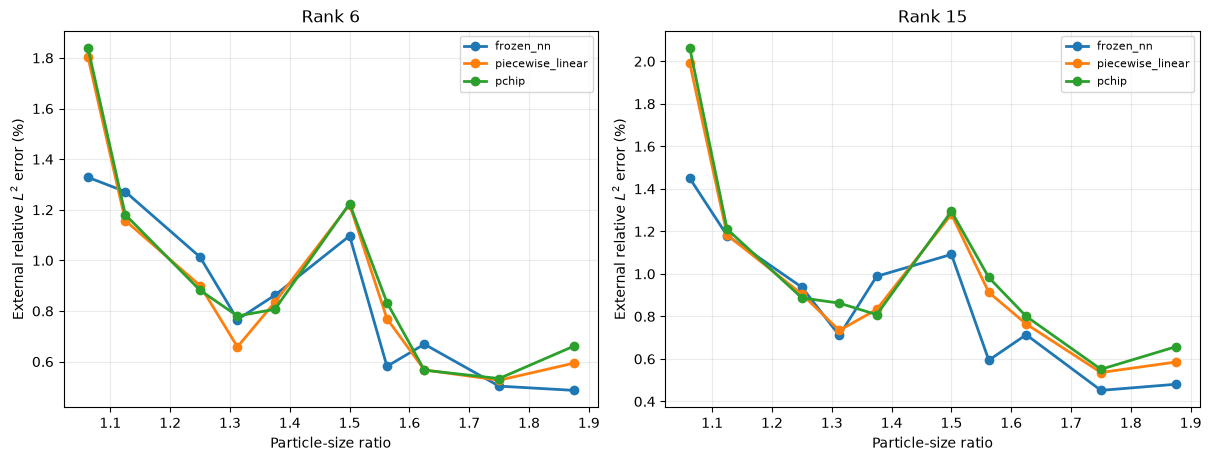

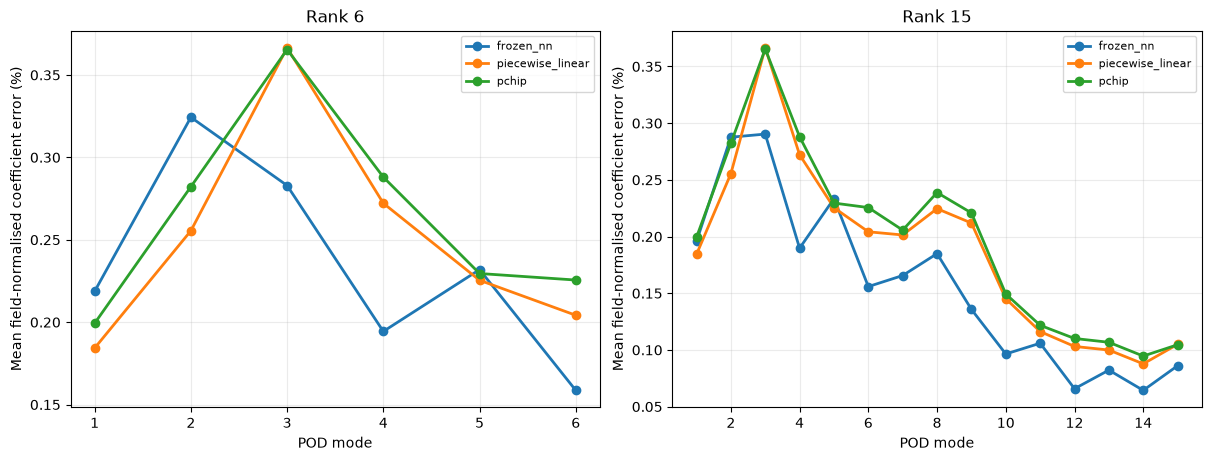

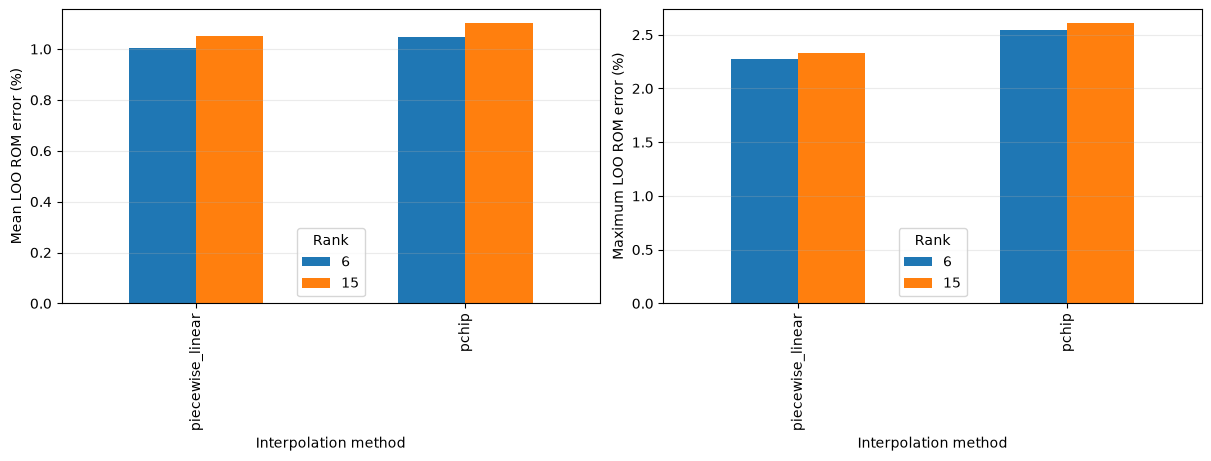

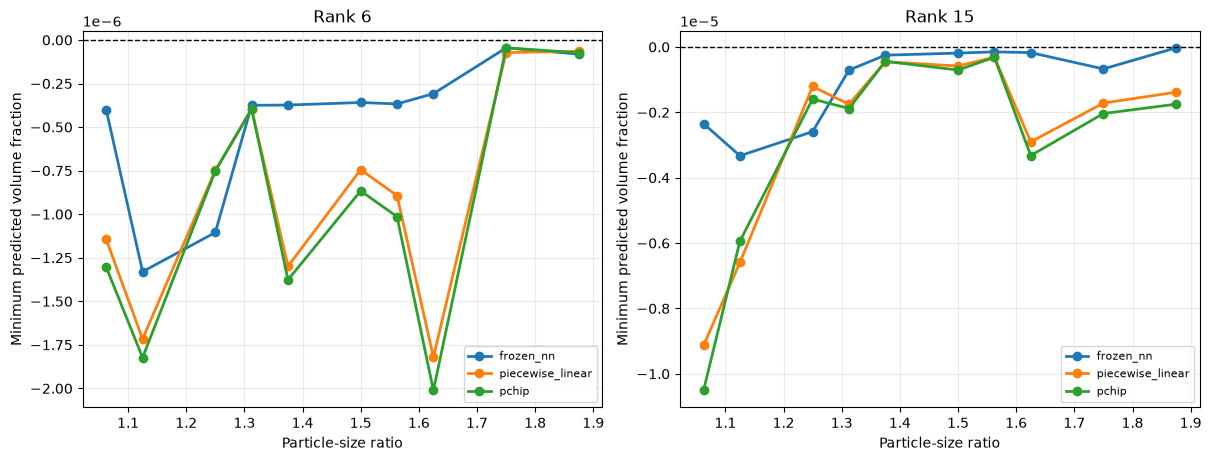

Saved Notebook 18 tables: 11
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/coefficient_baselines/frozen_input_audit.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/coefficient_baselines/frozen_case_reproduction_audit.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/coefficient_baselines/interpolation_node_audit.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/coefficient_baselines/method_case_results.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/coefficient_baselines/method_summary.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/coefficient_baselines/paired_method_summary.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/coefficient_baselines/modewise_results.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/coefficient_baselines/modewise_summary.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/coefficient_baselines

In [12]:
import matplotlib.pyplot as plt
from pathlib import Path


N18_TABLE_DIRECTORY = (
    N18_REPO_ROOT
    / "results"
    / "tables"
    / "coefficient_baselines"
)

N18_FIGURE_DIRECTORY = (
    N18_REPO_ROOT
    / "results"
    / "figures"
    / "coefficient_baselines"
)

N18_TABLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

N18_FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


N18_TABLE_PATHS = {
    "frozen_input_audit": (
        N18_TABLE_DIRECTORY
        / "frozen_input_audit.csv"
    ),
    "frozen_case_audit": (
        N18_TABLE_DIRECTORY
        / "frozen_case_reproduction_audit.csv"
    ),
    "interpolation_audit": (
        N18_TABLE_DIRECTORY
        / "interpolation_node_audit.csv"
    ),
    "method_case_results": (
        N18_TABLE_DIRECTORY
        / "method_case_results.csv"
    ),
    "method_summary": (
        N18_TABLE_DIRECTORY
        / "method_summary.csv"
    ),
    "paired_method_summary": (
        N18_TABLE_DIRECTORY
        / "paired_method_summary.csv"
    ),
    "modewise_results": (
        N18_TABLE_DIRECTORY
        / "modewise_results.csv"
    ),
    "modewise_summary": (
        N18_TABLE_DIRECTORY
        / "modewise_summary.csv"
    ),
    "loo_results": (
        N18_TABLE_DIRECTORY
        / "loo_interpolation_results.csv"
    ),
    "loo_summary": (
        N18_TABLE_DIRECTORY
        / "loo_interpolation_summary.csv"
    ),
}


N18_FIGURE_PATHS = {
    "external_method_error": (
        N18_FIGURE_DIRECTORY
        / "external_method_error"
    ),
    "external_modewise_error": (
        N18_FIGURE_DIRECTORY
        / "external_modewise_error"
    ),
    "loo_validation": (
        N18_FIGURE_DIRECTORY
        / "loo_interpolation_validation"
    ),
    "external_physical_diagnostics": (
        N18_FIGURE_DIRECTORY
        / "external_physical_diagnostics"
    ),
}


N18_FROZEN_AUDIT.to_csv(
    N18_TABLE_PATHS[
        "frozen_input_audit"
    ],
    index=False,
)

N18_FROZEN_CASE_AUDIT.to_csv(
    N18_TABLE_PATHS[
        "frozen_case_audit"
    ],
    index=False,
)

N18_INTERPOLATION_AUDIT.to_csv(
    N18_TABLE_PATHS[
        "interpolation_audit"
    ],
    index=False,
)

N18_EVALUATION_RESULTS.to_csv(
    N18_TABLE_PATHS[
        "method_case_results"
    ],
    index=False,
)

N18_METHOD_SUMMARY.to_csv(
    N18_TABLE_PATHS[
        "method_summary"
    ],
    index=False,
)

N18_PAIRED_SUMMARY.to_csv(
    N18_TABLE_PATHS[
        "paired_method_summary"
    ],
    index=False,
)

N18_MODEWISE_RESULTS.to_csv(
    N18_TABLE_PATHS[
        "modewise_results"
    ],
    index=False,
)

N18_MODEWISE_SUMMARY.to_csv(
    N18_TABLE_PATHS[
        "modewise_summary"
    ],
    index=False,
)

N18_LOO_RESULTS.to_csv(
    N18_TABLE_PATHS[
        "loo_results"
    ],
    index=False,
)

N18_LOO_SUMMARY.to_csv(
    N18_TABLE_PATHS[
        "loo_summary"
    ],
    index=False,
)


N18_METHOD_ORDER = [
    "frozen_nn",
    "piecewise_linear",
    "pchip",
]


def n18_model_title(model_name):
    return (
        "Rank 6"
        if model_name
        == "validation_selected_rank"
        else "Rank 15"
    )


# Figure 1: external case errors.
figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
    constrained_layout=True,
)

for n18_axis, n18_model_name in zip(
    axes,
    [
        "validation_selected_rank",
        "paper_rank15",
    ],
):

    n18_subset = (
        N18_EVALUATION_RESULTS.loc[
            (
                N18_EVALUATION_RESULTS[
                    "model"
                ].eq(n18_model_name)
            )
            & (
                N18_EVALUATION_RESULTS[
                    "evaluation_role"
                ].eq("external")
            )
        ]
    )

    for n18_method_name in (
        N18_METHOD_ORDER
    ):

        n18_group = (
            n18_subset.loc[
                n18_subset["method"].eq(
                    n18_method_name
                )
            ]
            .sort_values("size_ratio")
        )

        n18_axis.plot(
            n18_group["size_ratio"],
            n18_group["rom_error_percent"],
            marker="o",
            linewidth=2,
            label=n18_method_name,
        )

    n18_axis.set_title(
        n18_model_title(
            n18_model_name
        )
    )

    n18_axis.set_xlabel(
        "Particle-size ratio"
    )

    n18_axis.set_ylabel(
        r"External relative $L^2$ error (%)"
    )

    n18_axis.grid(
        True,
        alpha=0.25,
    )

    n18_axis.legend(
        fontsize=8,
    )

figure.savefig(
    str(
        N18_FIGURE_PATHS[
            "external_method_error"
        ]
    )
    + ".pdf",
    bbox_inches="tight",
)

figure.savefig(
    str(
        N18_FIGURE_PATHS[
            "external_method_error"
        ]
    )
    + ".png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


# Figure 2: external modewise errors.
figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
    constrained_layout=True,
)

for n18_axis, n18_model_name in zip(
    axes,
    [
        "validation_selected_rank",
        "paper_rank15",
    ],
):

    n18_subset = (
        N18_EXTERNAL_MODEWISE_SUMMARY.loc[
            N18_EXTERNAL_MODEWISE_SUMMARY[
                "model"
            ].eq(n18_model_name)
        ]
    )

    for n18_method_name in (
        N18_METHOD_ORDER
    ):

        n18_group = (
            n18_subset.loc[
                n18_subset["method"].eq(
                    n18_method_name
                )
            ]
            .sort_values("mode")
        )

        n18_axis.plot(
            n18_group["mode"],
            n18_group[
                "mean_field_normalised_error_percent"
            ],
            marker="o",
            linewidth=2,
            label=n18_method_name,
        )

    n18_axis.set_title(
        n18_model_title(
            n18_model_name
        )
    )

    n18_axis.set_xlabel(
        "POD mode"
    )

    n18_axis.set_ylabel(
        "Mean field-normalised coefficient error (%)"
    )

    n18_axis.grid(
        True,
        alpha=0.25,
    )

    n18_axis.legend(
        fontsize=8,
    )

figure.savefig(
    str(
        N18_FIGURE_PATHS[
            "external_modewise_error"
        ]
    )
    + ".pdf",
    bbox_inches="tight",
)

figure.savefig(
    str(
        N18_FIGURE_PATHS[
            "external_modewise_error"
        ]
    )
    + ".png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


# Figure 3: LOO interpolation validation.
figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
    constrained_layout=True,
)

for n18_axis, n18_metric, n18_ylabel in [
    (
        axes[0],
        "mean_rom_error_percent",
        "Mean LOO ROM error (%)",
    ),
    (
        axes[1],
        "maximum_rom_error_percent",
        "Maximum LOO ROM error (%)",
    ),
]:

    n18_plot = (
        N18_LOO_SUMMARY
        .pivot(
            index="method",
            columns="rank",
            values=n18_metric,
        )
        .reindex(
            [
                "piecewise_linear",
                "pchip",
            ]
        )
    )

    n18_plot.plot(
        kind="bar",
        ax=n18_axis,
    )

    n18_axis.set_xlabel(
        "Interpolation method"
    )

    n18_axis.set_ylabel(
        n18_ylabel
    )

    n18_axis.grid(
        True,
        axis="y",
        alpha=0.25,
    )

    n18_axis.legend(
        title="Rank",
    )

figure.savefig(
    str(
        N18_FIGURE_PATHS[
            "loo_validation"
        ]
    )
    + ".pdf",
    bbox_inches="tight",
)

figure.savefig(
    str(
        N18_FIGURE_PATHS[
            "loo_validation"
        ]
    )
    + ".png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


# Figure 4: external physical diagnostics.
figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
    constrained_layout=True,
)

for n18_axis, n18_model_name in zip(
    axes,
    [
        "validation_selected_rank",
        "paper_rank15",
    ],
):

    n18_subset = (
        N18_EVALUATION_RESULTS.loc[
            (
                N18_EVALUATION_RESULTS[
                    "model"
                ].eq(n18_model_name)
            )
            & (
                N18_EVALUATION_RESULTS[
                    "evaluation_role"
                ].eq("external")
            )
        ]
    )

    for n18_method_name in (
        N18_METHOD_ORDER
    ):

        n18_group = (
            n18_subset.loc[
                n18_subset["method"].eq(
                    n18_method_name
                )
            ]
            .sort_values("size_ratio")
        )

        n18_axis.plot(
            n18_group["size_ratio"],
            n18_group[
                "minimum_prediction"
            ],
            marker="o",
            linewidth=2,
            label=n18_method_name,
        )

    n18_axis.axhline(
        0.0,
        color="black",
        linestyle="--",
        linewidth=1,
    )

    n18_axis.set_title(
        n18_model_title(
            n18_model_name
        )
    )

    n18_axis.set_xlabel(
        "Particle-size ratio"
    )

    n18_axis.set_ylabel(
        "Minimum predicted volume fraction"
    )

    n18_axis.grid(
        True,
        alpha=0.25,
    )

    n18_axis.legend(
        fontsize=8,
    )

figure.savefig(
    str(
        N18_FIGURE_PATHS[
            "external_physical_diagnostics"
        ]
    )
    + ".pdf",
    bbox_inches="tight",
)

figure.savefig(
    str(
        N18_FIGURE_PATHS[
            "external_physical_diagnostics"
        ]
    )
    + ".png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


N18_OUTPUT_ARTIFACT_PATHS = [
    *N18_TABLE_PATHS.values(),
    *[
        Path(str(path) + suffix)
        for path in N18_FIGURE_PATHS.values()
        for suffix in [".pdf", ".png"]
    ],
]


assert all(
    path.is_file()
    for path in N18_OUTPUT_ARTIFACT_PATHS
)


N18_VALIDATION_AUDIT = pd.DataFrame(
    [
        {
            "check": "frozen_input_hashes",
            "passed": bool(
                N18_PREFLIGHT_AUDIT[
                    "hash_match"
                ].all()
            ),
            "value": True,
        },
        {
            "check": "frozen_case_reproduction",
            "passed": True,
            "value": float(
                N18_FROZEN_CASE_AUDIT[
                    "maximum_case_error_difference_percent"
                ].max()
            ),
        },
        {
            "check": "external_case_count",
            "passed": len(
                N18_EXTERNAL_SUMMARY[
                    "case_count"
                ].unique()
            ) == 1
            and int(
                N18_EXTERNAL_SUMMARY[
                    "case_count"
                ].iloc[0]
            ) == 10,
            "value": 10,
        },
        {
            "check": "internal_validation_case_count",
            "passed": len(
                N18_INTERNAL_VALIDATION_SUMMARY[
                    "case_count"
                ].unique()
            ) == 1
            and int(
                N18_INTERNAL_VALIDATION_SUMMARY[
                    "case_count"
                ].iloc[0]
            ) == 10,
            "value": 10,
        },
        {
            "check": "pythagorean_decomposition",
            "passed": (
                n18_max_pythagorean_residual
                < 1e-12
            ),
            "value": n18_max_pythagorean_residual,
        },
        {
            "check": "loo_interior_case_count",
            "passed": (
                len(N18_LOO_RESULTS)
                == 2 * 2 * 88
            ),
            "value": len(N18_LOO_RESULTS),
        },
        {
            "check": "loo_endpoint_exclusion",
            "passed": True,
            "value": [
                float(N18_FITTING_PARAMETERS[0]),
                float(N18_FITTING_PARAMETERS[-1]),
            ],
        },
        {
            "check": "external_non_leakage",
            "passed": True,
            "value": False,
        },
        {
            "check": "all_results_finite",
            "passed": bool(
                np.isfinite(
                    N18_EVALUATION_RESULTS.select_dtypes(
                        include=[np.number]
                    ).to_numpy()
                ).all()
            ),
            "value": True,
        },
        {
            "check": "artifact_existence",
            "passed": all(
                path.is_file()
                for path in N18_OUTPUT_ARTIFACT_PATHS
            ),
            "value": len(
                N18_OUTPUT_ARTIFACT_PATHS
            ),
        },
    ]
)


assert N18_VALIDATION_AUDIT[
    "passed"
].all()


N18_VALIDATION_AUDIT.to_csv(
    N18_TABLE_DIRECTORY
    / "validation_audit.csv",
    index=False,
)

N18_OUTPUT_ARTIFACT_PATHS.append(
    N18_TABLE_DIRECTORY
    / "validation_audit.csv"
)

assert all(
    path.is_file()
    for path in N18_OUTPUT_ARTIFACT_PATHS
)


print(
    "Saved Notebook 18 tables:",
    len(N18_TABLE_PATHS) + 1,
)

for path in N18_TABLE_PATHS.values():
    print(path)

print(
    N18_TABLE_DIRECTORY
    / "validation_audit.csv"
)

print(
    "Saved Notebook 18 figures:",
    len(N18_FIGURE_PATHS) * 2,
)

for path in N18_OUTPUT_ARTIFACT_PATHS:
    if path.suffix in [
        ".pdf",
        ".png",
    ]:
        print(path)

print(
    "Maximum Pythagorean residual:",
    n18_max_pythagorean_residual,
)

print(
    "Maximum LOO residual:",
    n18_loo_max_residual,
)

print(
    "External cases used for interpolation construction:",
    False,
)

print(
    "Final manifest created:",
    False,
)

print(
    "Notebook 18 tables and figures saved successfully:",
    True,
)

# Notebook 18 — findings and limitations

The frozen neural networks reproduce the saved Notebook 14 external results to machine precision. The maximum casewise reproduction difference is approximately $2.2\times10^{-16}$ percentage points, and repeated inference is deterministic.

For the external cases, the rank-$6$ frozen network has mean relative $L^2$ error $0.857850\%$, median error $0.814311\%$ and maximum error $1.328504\%$. The rank-$15$ frozen network has mean error $0.859868\%$, median error $0.825467\%$ and maximum error $1.449864\%$. Their corresponding mean POD projection errors are $0.533321\%$ and $0.361168\%$, so the remaining error is associated with coefficient prediction inside the retained POD spaces.

The interpolation baselines perform slightly worse on the external cases. Piecewise-linear interpolation gives mean errors of $0.903362\%$ for rank $6$ and $0.972520\%$ for rank $15$. PCHIP gives mean errors of $0.930826\%$ and $1.011759\%, respectively. The same ordering is observed on the ten internal-validation cases.

Interpolation is exact at its 90 fitting nodes up to floating-point precision. The leave-one-fitting-node-out diagnostic provides a more meaningful interpolation test because each interior node is predicted from the other 89 nodes. Piecewise-linear interpolation gives mean LOO ROM errors of $1.004672\%$ for rank $6$ and $1.050420\%$ for rank $15$. PCHIP gives $1.048880\%$ and $1.101064\%, respectively. Both endpoints, $\mu=1$ and $\mu=2$, are excluded from this diagnostic because endpoint removal would require extrapolation.

The error decomposition is evaluated for every case using

$$
e_{\mathrm{ROM}}^2
=
e_{\mathrm{POD}}^2
+
e_{\mathrm{coef}}^2.
$$

The largest residual is approximately $9.3\times10^{-18}$ across the main evaluation and $1.1\times10^{-17}$ across the LOO diagnostic.

The conclusions are conditional on the frozen uncentred POD bases stored by Notebook 14. Those bases were constructed from all 100 training-collection fields, including the ten coefficient-validation fields. The interpolation comparison therefore assesses coefficient maps conditional on the fixed bases; it is not a completely training-only re-estimation of the POD basis and surrogate.

The ten external cases were not used to construct, tune or select any method. They had already been inspected earlier in the project, so this is a retrospective external comparison rather than a newly blind test. The interpolation results describe the behaviour of the tested baselines and do not establish that interpolation is the unique or optimal alternative surrogate.

In [15]:
import hashlib
import json
from pathlib import Path


def n18_final_sha256(path):
    digest = hashlib.sha256()

    with Path(path).open(
        "rb"
    ) as handle:

        for chunk in iter(
            lambda: handle.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


N18_NOTEBOOK_PATH = (
    N18_REPO_ROOT
    / "notebooks"
    / "18_coefficient_baselines_and_validation.ipynb"
)

N18_FINAL_MANIFEST_PATH = (
    N18_TABLE_DIRECTORY
    / "notebook18_final_integrity_manifest.json"
)


assert N18_NOTEBOOK_PATH.is_file()


N18_NOTEBOOK_JSON = json.loads(
    N18_NOTEBOOK_PATH.read_text(
        encoding="utf-8"
    )
)


N18_STORED_ERRORS = []
N18_STORED_STDERR = []

for n18_cell_index, n18_cell in enumerate(
    N18_NOTEBOOK_JSON["cells"],
    start=1,
):

    for n18_output in n18_cell.get(
        "outputs",
        [],
    ):

        if (
            n18_output.get(
                "output_type"
            )
            == "error"
        ):

            N18_STORED_ERRORS.append(
                {
                    "cell": n18_cell_index,
                    "ename": n18_output.get(
                        "ename"
                    ),
                    "evalue": n18_output.get(
                        "evalue"
                    ),
                }
            )

        if (
            n18_output.get(
                "output_type"
            )
            == "stream"
            and n18_output.get(
                "name"
            )
            == "stderr"
        ):

            N18_STORED_STDERR.append(
                n18_cell_index
            )


assert not N18_STORED_ERRORS
assert not N18_STORED_STDERR


N18_EXECUTION_COUNTS = [
    n18_cell.get(
        "execution_count"
    )
    for n18_cell in N18_NOTEBOOK_JSON[
        "cells"
    ]
    if (
        n18_cell.get(
            "cell_type"
        )
        == "code"
        and n18_cell.get(
            "execution_count"
        )
        is not None
    )
]


N18_RECORDS = []


def n18_add_record(
    path,
    role,
):

    path = Path(path)

    assert path.is_file()

    N18_RECORDS.append(
        {
            "relative_path": str(
                path.relative_to(
                    N18_REPO_ROOT
                )
            ),
            "role": role,
            "size_bytes": path.stat().st_size,
            "sha256": n18_final_sha256(
                path
            ),
        }
    )


for n18_role, n18_path in (
    N18_INPUT_PATHS.items()
):

    n18_add_record(
        n18_path,
        f"trusted_input:{n18_role}",
    )


n18_add_record(
    N18_NOTEBOOK_PATH,
    "notebook",
)


for n18_name, n18_path in (
    N18_TABLE_PATHS.items()
):

    n18_add_record(
        n18_path,
        f"table_artifact:{n18_name}",
    )


n18_add_record(
    N18_TABLE_DIRECTORY
    / "validation_audit.csv",
    "table_artifact:validation_audit",
)


for n18_name, n18_base_path in (
    N18_FIGURE_PATHS.items()
):

    n18_add_record(
        Path(
            str(n18_base_path)
            + ".pdf"
        ),
        f"figure_artifact:{n18_name}:pdf",
    )

    n18_add_record(
        Path(
            str(n18_base_path)
            + ".png"
        ),
        f"figure_artifact:{n18_name}:png",
    )


N18_RECORDED_PATHS = [
    record["relative_path"]
    for record in N18_RECORDS
]

assert len(
    N18_RECORDED_PATHS
) == len(
    set(N18_RECORDED_PATHS)
)


N18_FINAL_MANIFEST = {
    "schema_version": 1,
    "manifest_type": (
        "Notebook 18 final integrity manifest"
    ),
    "notebook": str(
        N18_NOTEBOOK_PATH.relative_to(
            N18_REPO_ROOT
        )
    ),
    "notebook_sha256": n18_final_sha256(
        N18_NOTEBOOK_PATH
    ),
    "notebook_metadata": {
        "cell_count": len(
            N18_NOTEBOOK_JSON[
                "cells"
            ]
        ),
        "nonempty_code_cell_count": sum(
            1
            for n18_cell in N18_NOTEBOOK_JSON[
                "cells"
            ]
            if (
                n18_cell.get(
                    "cell_type"
                )
                == "code"
                and "".join(
                    n18_cell.get(
                        "source",
                        [],
                    )
                ).strip()
            )
        ),
        "execution_counts": (
            N18_EXECUTION_COUNTS
        ),
        "stored_errors": (
            N18_STORED_ERRORS
        ),
        "stored_stderr_cells": (
            N18_STORED_STDERR
        ),
    },
    "methodology": {
        "ranks": [6, 15],
        "methods": [
            "frozen_nn",
            "piecewise_linear",
            "pchip",
        ],
        "fitting_case_count": 90,
        "internal_validation_case_count": 10,
        "external_case_count": 10,
        "loo_interior_case_count": 88,
        "loo_endpoints_excluded": True,
        "negative_prediction_threshold": -1e-4,
        "pod_formulation": "uncentred",
        "coefficient_scaling": "none",
    },
    "scientific_checks": {
        "maximum_main_pythagorean_residual": (
            n18_max_pythagorean_residual
        ),
        "maximum_loo_pythagorean_residual": (
            n18_loo_max_residual
        ),
        "maximum_frozen_case_reproduction_difference": (
            float(
                N18_FROZEN_CASE_AUDIT[
                    "maximum_case_error_difference_percent"
                ].max()
            )
        ),
        "external_cases_used_for_interpolation": False,
        "external_cases_used_for_selection": False,
        "raw_dem_files_accessed": False,
        "all_validation_checks_passed": bool(
            N18_VALIDATION_AUDIT[
                "passed"
            ].all()
        ),
    },
    "scope": {
        "external_comparison": (
            "retrospective"
        ),
        "basis_scope": (
            "fixed Notebook 14 bases constructed "
            "from the complete 100-field training collection"
        ),
        "raw_particle_files_hashed": False,
        "raw_external_coarse_grained_files_hashed": False,
    },
    "recorded_file_count": len(
        N18_RECORDS
    ),
    "records": N18_RECORDS,
    "manifest_self_hash_excluded": True,
}


N18_FINAL_MANIFEST_PATH.write_text(
    json.dumps(
        N18_FINAL_MANIFEST,
        indent=2,
        sort_keys=True,
    )
    + "\n",
    encoding="utf-8",
)


N18_MANIFEST_SHA256 = n18_final_sha256(
    N18_FINAL_MANIFEST_PATH
)


N18_RELOADED_MANIFEST = json.loads(
    N18_FINAL_MANIFEST_PATH.read_text(
        encoding="utf-8"
    )
)

assert (
    N18_RELOADED_MANIFEST[
        "recorded_file_count"
    ]
    == len(N18_RECORDS)
)

assert (
    N18_FINAL_MANIFEST_PATH
    not in [
        N18_REPO_ROOT
        / record["relative_path"]
        for record in N18_RECORDS
    ]
)

assert all(
    (
        N18_REPO_ROOT
        / record["relative_path"]
    ).is_file()
    for record in N18_RECORDS
)

print(
    "Final manifest:",
    N18_FINAL_MANIFEST_PATH,
)

print(
    "Final manifest SHA-256:",
    N18_MANIFEST_SHA256,
)

print(
    "Notebook SHA-256:",
    N18_FINAL_MANIFEST[
        "notebook_sha256"
    ],
)

print(
    "Recorded files:",
    len(N18_RECORDS),
)

print(
    "Notebook cells:",
    len(
        N18_NOTEBOOK_JSON[
            "cells"
        ]
    ),
)

print(
    "Stored notebook errors:",
    N18_STORED_ERRORS,
)

print(
    "Stored stderr cells:",
    N18_STORED_STDERR,
)

print(
    "Raw DEM files accessed:",
    False,
)

print(
    "External cases used for interpolation construction:",
    False,
)

print(
    "Final manifest integrity verification passed:",
    True,
)

Final manifest: /Users/rallen/Documents/msc-rom-particle-systems/results/tables/coefficient_baselines/notebook18_final_integrity_manifest.json
Final manifest SHA-256: 1bf3355e381a490d37f56c000cb0db6becf14262807a141b6c8f778554b9b83b
Notebook SHA-256: b6e406021c6470b64123322260c06a361aa1041a9b7932457a6cc7556cd89305
Recorded files: 27
Notebook cells: 14
Stored notebook errors: []
Stored stderr cells: []
Raw DEM files accessed: False
External cases used for interpolation construction: False
Final manifest integrity verification passed: True
